# Extraction de Keywords

## Imports

In [7]:
import os
import yake, pandas as pd
from pathlib import Path

## Extraire les mots clés d'un document avec Yake

https://github.com/LIAAD/yake

In [8]:
# Instantier l'extracteur de mots clés
kw_extractor = yake.KeywordExtractor(lan="fr", n=2,top=50)
kw_extractor

In [ ]:

data_path = Path("../../data/txt")
if not data_path.exists():
    data_path = Path("C:/Users/aspngp/Downloads/tac/data/txt")

files = [f.name for f in data_path.glob('*.txt')]
kw_extractor = yake.KeywordExtractor(lan="fr", top=100)

YEAR = "1950"
global_kw = defaultdict(list)

for f in sorted(files):
    if YEAR not in f:          
        continue
    text = open(data_path / f, 'r', encoding="utf-8").read()
    keywords = kw_extractor.extract_keywords(text)

    kept = [kw for kw, score in keywords if len(kw.replace('\xa0', ' ').split()) == 2]
    if kept:
        print(f"{f} mentions these keywords: {', '.join(kept[:5])}...")

    for kw, score in keywords:  
        if len(kw.replace('\xa0', ' ').split()) == 2:
            global_kw[kw].append(score)

print(f"\n--- Top bigrammes {YEAR} ---")
for kw, scores in sorted(global_kw.items(), key=lambda kv: sum(kv[1])/len(kv[1]))[:30]:
    print(f"{kw}\t{sum(scores)/len(scores):.3f}")

KB_JB838_1950-01-06_01-00002.txt mentions these keywords: consultation populaire, Henri Matisse, Mario Uchard, Comité franco-belge, locataire principal...
KB_JB838_1950-01-07_01-00013.txt mentions these keywords: Bruxelles Tél, France AUTO, rue Longtin, Bas prix, Lambiotte Tél...
KB_JB838_1950-01-08_01-00011.txt mentions these keywords: BELLE MAISON, l'heure Studio, Agence Rossel, louer VILLA, rue Jourdan...
KB_JB838_1950-01-10_01-00006.txt mentions these keywords: Van Hassel, CYCLISME Week-end, bat Van, tombe Van, Van Kerrebroeck...
KB_JB838_1950-01-15_01-00010.txt mentions these keywords: Laeken Daniel, Annuelle LINGERIE, LINGERIE KLAMC, RÉÉQUIPEMENT MÉNAGER, TENTATION fondée...
KB_JB838_1950-01-22_01-00014.txt mentions these keywords: Agence Rossel, QUASI ILLIMITEE, EMPLOIE UNIQUEMENT, ENGRENAGES GARANTISSANT, PRECISION ABSOLUE...
KB_JB838_1950-02-13_01-00005.txt mentions these keywords: Van den, Van Pottelberghe, Van Rompaey, Van Looy, Van Brustegem...
KB_JB838_1950-02-13_01-00008.

In [39]:
# Stocker le contenu de ces fichiers dans une liste
from pathlib import Path

data_path = Path("../../data/txt") if Path("../../data/txt").exists() else Path("C:/Users/aspngp/Downloads/tac/data/txt")

#fichiers de 1950
files_1950 = [f.name for f in data_path.glob('*.txt') if "1950" in f.name]

# contenu
content_list = []
for filename in sorted(files_1950):
    with open(data_path / filename, 'r', encoding='utf-8') as f:
        content_list.append(f.read())

print(f"Nombre de documents chargés pour 1950 : {len(content_list)}")

Nombre de documents chargés pour 1950 : 100


In [40]:
# Imprimer le nombre de fichiers identifiés
len(files)

1

In [41]:
# Récupération d'un fichier de 1950
files_1950 = [f.name for f in data_path.glob('*.txt') if "1950" in f.name]

if files_1950:
    filename = files_1950[0]  # Sélection du premier fichier trouvé
    print(f"Fichier sélectionné : {filename}\n")
# Lecture du texte
    text = open(data_path / filename, 'r', encoding="utf-8").read()

Fichier sélectionné : KB_JB838_1950-01-06_01-00002.txt



In [42]:
# Extraire les mots clés de ce texte
kw_extractor = yake.KeywordExtractor(lan="fr", n=2, top=50)
keywords = kw_extractor.extract_keywords(text)

In [28]:
# Ne garder que les bigrammes
kept = []
for kw, score in keywords:
    words = kw.split()
    if len(words) == 2:
        kept.append(kw)
kept

['consultation populaire',
 'Henri Matisse',
 'Mario Uchard',
 'Comité franco-belge',
 'locataire principal',
 'qu’il faut',
 'jeune homme',
 'd’un parti',
 'Léopold III']

In [ ]:
# Tester d'autres paramètres YAKE (ex: n-grammes de 1 à 3 mots)

if files_1950:
    custom_extractor = yake.KeywordExtractor(
        lan="fr", 
        n=3, 
        dedupLim=0.9, 
        top=30
    )

    keywords_multi = custom_extractor.extract_keywords(text)

    print(f"\n--- Top 30 mots-clés (1 à 3 mots) pour {filename} ---")
    for kw, score in keywords_multi:
        kw_clean = kw.replace('\xa0', ' ')
        print(f"{kw_clean}\t{score:.3f}")


--- Top 30 mots-clés (1 à 3 mots) pour KB_JB838_1950-01-06_01-00002.txt ---
rue	0.026
heures	0.027
nullement d’autre cliese	0.027
qu’il	0.027
Paris	0.029
capitaine	0.031
Thérèse	0.035
capitaine Mac Donald	0.049
fut	0.053
matin	0.054
Bruxelles	0.055
soir	0.056
Van de Zande	0.057
fois	0.061
Dubuc	0.062
police	0.062
trouvait	0.064
ans	0.064
Sauvetage	0.067
qu’elle	0.068
temps	0.069
New-York	0.069
mer	0.069
jour	0.075
nuit	0.080
capitaine Mac	0.081
Lachaud	0.082
Octave	0.083
Flandre	0.084
voleurs	0.087


In [43]:
# Imprimer les 200 premiers caractères du contenu du premier fichier
content_list[0][0:200]



'/ LE SOIR Une importante manifestation franco-belge Le Comité franco-belge du Commerce, de l’Industrie et de l’Agriculture qui. au cours de l’année écoulée et dans les circonstances les plus difficile'

In [45]:
# Ecrire tout le contenu dans un fichier temporaire
temp_path = '../data/tmp'
if not os.path.exists(temp_path):
    os.mkdir(temp_path)
with open(os.path.join(temp_path, f'{1950}.txt'), 'w', encoding='utf-8') as f:
    f.write(' '.join(content_list))

In [46]:
# Imprimer le contenu du fichier et constater les "déchets"
with open(os.path.join(temp_path, f'{1950}.txt'), 'r', encoding='utf-8') as f:
    before = f.read()

before[:500]

'/ LE SOIR Une importante manifestation franco-belge Le Comité franco-belge du Commerce, de l’Industrie et de l’Agriculture qui. au cours de l’année écoulée et dans les circonstances les plus difficiles a rendu aux relations économiques entre les deux pays des services considérables, donnera le 12 janvier, à 19 h. 30, un dîner à l’occasion de l’anniversaire de son installation. Ce comité, qui fonctionne à Bruxelles sous la présidence de M. André Vlimant, a permis de réaliser d’importants échanges'

In [62]:
import nltk
from pathlib import Path

def clean_text(year="1950", folder="../../data/txt", output_dir="."):
    # Conversion explicite en chaîne de caractères
    year_str = str(year)
    
    # nom de variable (folder)
    data_path = Path(folder) if Path(folder).exists() else Path("C:/Users/aspngp/Downloads/tac/data/txt")
    output_path = Path(output_dir) / f"{year_str}_clean.txt"
    
    # Filtrage avec year_str
    files = [f for f in data_path.glob('*.txt') if year_str in f.name]
    
    if not files:
        return f"Erreur : Aucun fichier trouvé pour l'année {year_str} dans {data_path}."

    # Lecture et fusion des contenus
    full_text = ""
    for file_path in sorted(files):
        with open(file_path, 'r', encoding='utf-8') as f:
            full_text += f.read() + " "
    
    # Récupération des stopwords 
    stopwords_set = sw_custom if 'sw_custom' in globals() else (sw if 'sw' in globals() else set())

    # Tokenisation et filtrage
    words = nltk.wordpunct_tokenize(full_text)
    kept = [w.upper() for w in words if len(w) > 2 and w.isalpha() and w.lower() not in stopwords_set]
    kept_string = " ".join(kept)
    
    # Écriture du fichier nettoyé
    with open(output_path, "w", encoding='utf-8') as output:
        output.write(kept_string)
        
    return f'Output has been written in {output_path}!'

print(clean_text(1950))

Output has been written in 1950_clean.txt!


In [66]:
# Vérifier le résultat
year = "1950"
temp_path = "."  # Dossier où le fichier a été enregistré

# Vérifier le résultat
with open(os.path.join(temp_path, f'{year}_clean.txt'), 'r', encoding='utf-8') as f:
    after = f.read()

print(after[:500])

SOIR UNE IMPORTANTE MANIFESTATION FRANCO BELGE COMITÉ FRANCO BELGE COMMERCE INDUSTRIE AGRICULTURE QUI COURS ANNÉE ÉCOULÉE DANS LES CIRCONSTANCES LES PLUS DIFFICILES RENDU AUX RELATIONS ÉCONOMIQUES ENTRE LES DEUX PAYS DES SERVICES CONSIDÉRABLES DONNERA JANVIER DÎNER OCCASION ANNIVERSAIRE SON INSTALLATION COMITÉ QUI FONCTIONNE BRUXELLES SOUS PRÉSIDENCE ANDRÉ VLIMANT PERMIS RÉALISER IMPORTANTS ÉCHANGES COMPENSÉS NOTAMMENT DANS DOMAINE INDUSTRIE AGRICULTURE CES TRANSACTIONS DÉPASSANT HEURE ACTUELLE 


In [68]:
frequencies = Counter(after.split())
print(frequencies.most_common(10))

[('LES', 6440), ('DES', 5163), ('UNE', 3375), ('POUR', 2973), ('EST', 2948), ('PAR', 2716), ('QUE', 2632), ('QUI', 2487), ('DANS', 2443), ('ROSSEL', 2322)]


In [67]:
import nltk
import matplotlib.pyplot as plt
from pathlib import Path
from wordcloud import WordCloud
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# chargement du fichier nettoyé 1950_clean.txt
clean_file = Path("1950_clean.txt")

if clean_file.exists():
    with open(clean_file, 'r', encoding='utf-8') as f:
        text_1950 = f.read()
else:
    data_path = Path("../../data/txt") if Path("../../data/txt").exists() else Path("C:/Users/aspngp/Downloads/tac/data/txt")
    files = [f for f in data_path.glob('*.txt') if "1950" in f.name]
    text_1950 = " ".join([open(f, 'r', encoding='utf-8').read() for f in files])

# Stopwords de base en français
sw = set(stopwords.words('french'))

In [70]:
# Stopwords (Idem que dans s1)
sw = stopwords.words("french")
sw += ["les", "plus", "cette", "fait", "faire", "être", "deux", "comme", "dont", "tout",
       "ils", "bien", "sans", "peut", "tous", "après", "ainsi", "donc", "cet", "sous",
       "celle", "entre", "encore", "toutes", "pendant", "moins", "dire", "cela", "non",
       "faut", "trois", "aussi", "dit", "avoir", "doit", "contre", "depuis", "autres",
       "van", "het", "autre", "jusqu", "ville", "rossel", "dem"]
sw = set(sw)

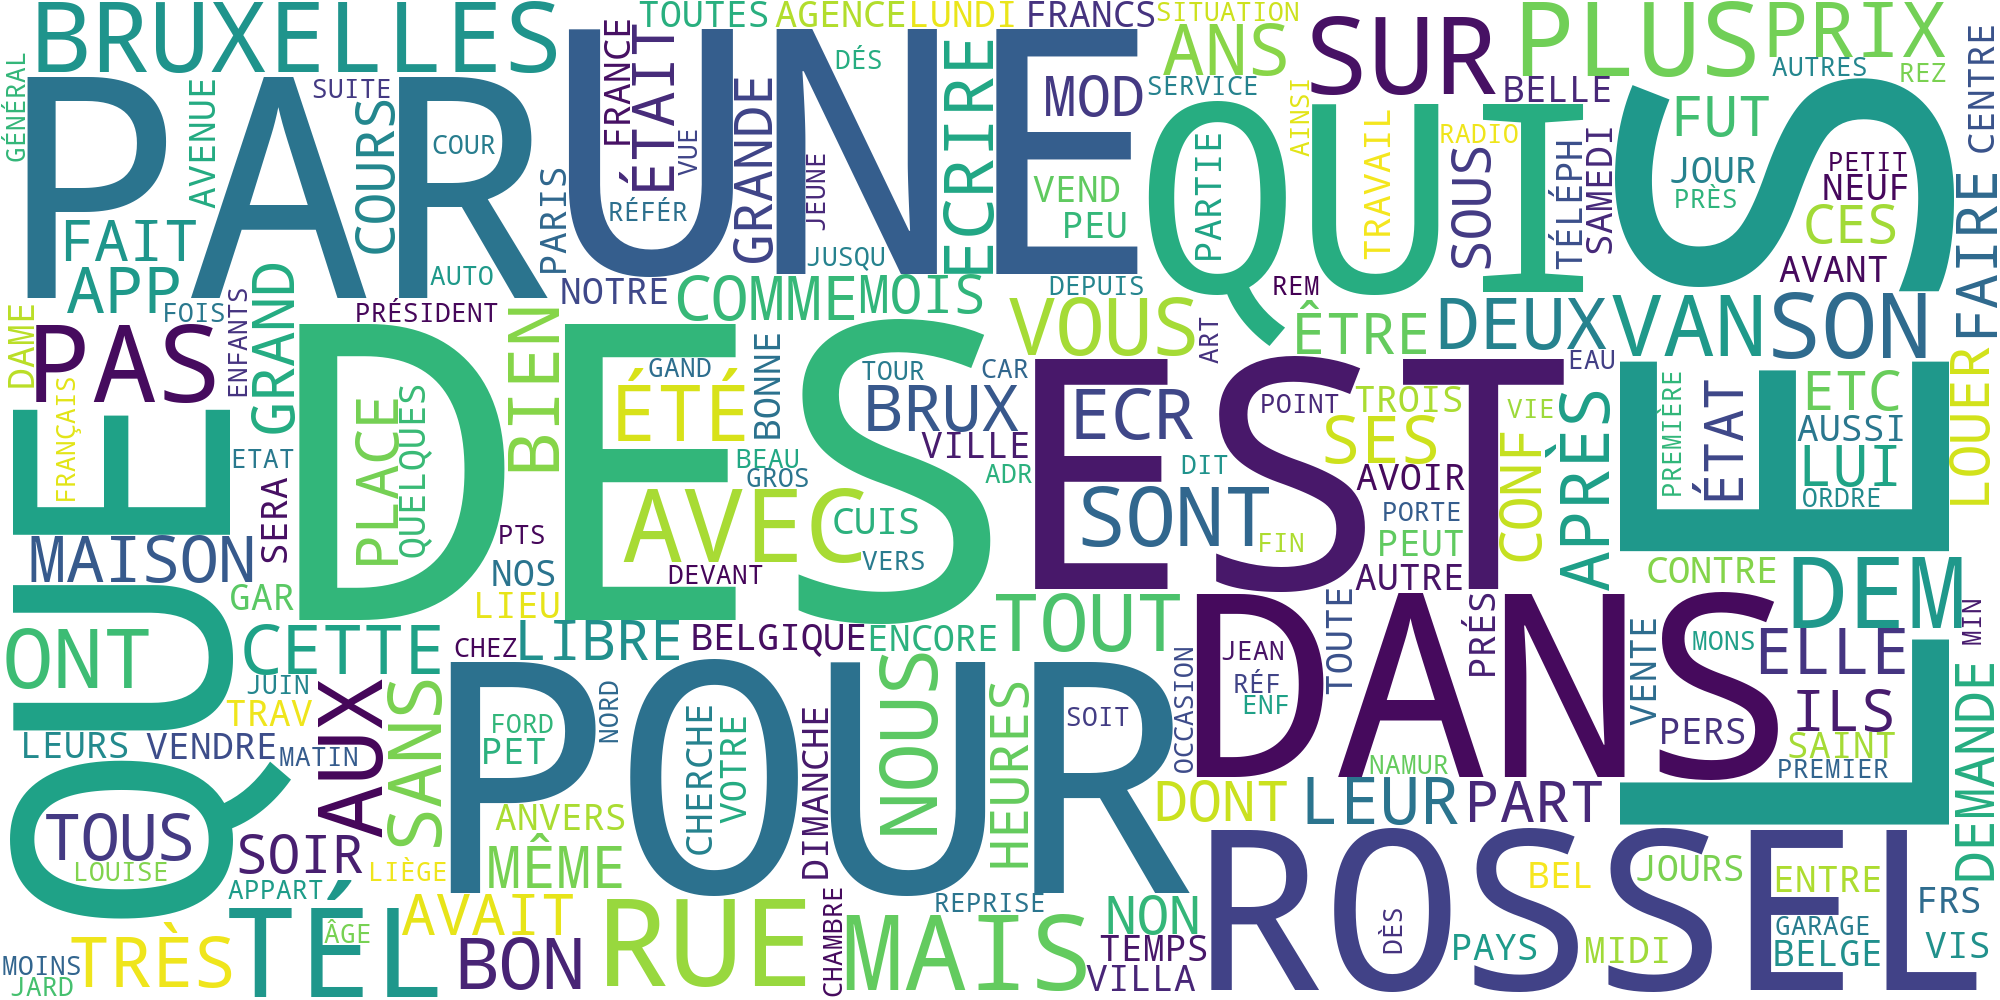

In [71]:
cloud = WordCloud(width=2000, height=1000, background_color='white').generate_from_frequencies(frequencies)
cloud.to_file(os.path.join(temp_path, f"{year}.png"))
Image(filename=os.path.join(temp_path, f"{year}.png"))

In [89]:
from collections import defaultdict
import spacy
from spacy.lang.fr.examples import sentences
%pip install  fr_core_news_md

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
nlp = spacy.load('fr_core_news_md')

In [75]:
data_path = Path("../../data/txt") if Path("../../data/txt").exists() else Path("C:/Users/aspngp/Downloads/tac/data/txt")

YEAR = "1950"
files_1950 = [f for f in data_path.glob('*.txt') if YEAR in f.name]
print(f"Fichiers trouvés pour {YEAR} : {len(files_1950)}")

# Lecture et agrégation du texte de 1950
texts = []
for file_path in sorted(files_1950):
    with open(file_path, 'r', encoding='utf-8') as f:
        texts.append(f.read().replace('\xa0', ' '))

full_text = " ".join(texts)
print(f"Volume de texte à analyser : {len(full_text)} caractères")

Fichiers trouvés pour 1950 : 100
Volume de texte à analyser : 3608591 caractères


In [77]:
# Charger le texte
n=1000000
text = open(r"C:/Users/aspng/Downloads/tac/tps/data/tmp/1950_clean.txt", encoding='utf-8').read()[:n]

In [78]:
%%time
# Traiter le texte

doc = nlp(text)

CPU times: total: 0 ns
Wall time: 7 ms


In [92]:
# Compter les entités
from collections import defaultdict

doc = nlp(full_text[:1000000])

# comptage des entités
people = defaultdict(int)
locations = defaultdict(int)
organisations = defaultdict(int)

for ent in doc.ents:
    clean_ent = ent.text.strip().replace('\n', ' ')
    if len(clean_ent) > 3:
        if ent.label_ == "PER":
            people[clean_ent] += 1
        elif ent.label_ == "LOC":
            locations[clean_ent] += 1
        elif ent.label_ == "ORG":
            organisations[clean_ent] += 1
           

In [94]:
# Affichage des résultats
print("\n=== TOP PERSONNES ===")
for person, freq in sorted(people.items(), key=lambda kv: kv[1], reverse=True)[:30]:
    print(f"{person:<35} | {freq} fois")




=== TOP PERSONNES ===
Rossel                              | 274 fois
Ecrire Ag                           | 34 fois
Mozart                              | 27 fois
trav                                | 27 fois
Beethoven                           | 15 fois
Aoûn                                | 13 fois
Brahms                              | 12 fois
Louise                              | 11 fois
Bach                                | 11 fois
Royal                               | 11 fois
Billotte                            | 11 fois
atel                                | 10 fois
Wagner                              | 10 fois
Charles Bernard                     | 10 fois
Matisse                             | 9 fois
Eric                                | 9 fois
Agence Rossel                       | 9 fois
Molière                             | 9 fois
Jacobs                              | 9 fois
Liszt                               | 9 fois
Debussy                             | 9 fois
Bonne            

In [95]:
print("\n TOP LIEUX ===")
for loc, freq in sorted(locations.items(), key=lambda kv: kv[1], reverse=True)[:30]:
    print(f"{loc:<35} | {freq} fois")




 TOP LIEUX ===
Bruxelles                           | 180 fois
Brux                                | 90 fois
Anvers                              | 58 fois
Belgique                            | 54 fois
Gand                                | 50 fois
Téléph                              | 48 fois
Paris                               | 44 fois
Liège                               | 41 fois
Etat                                | 40 fois
Mons                                | 31 fois
état                                | 30 fois
Namur                               | 28 fois
Allemagne                           | 27 fois
Anderlecht                          | 26 fois
Uccle                               | 24 fois
BRUXELLES                           | 24 fois
de France                           | 23 fois
Suisse                              | 22 fois
Schaerbeek                          | 21 fois
Forest                              | 20 fois
Laeken                              | 19 fois
Wavre            

In [96]:
print("\n=== TOP ORGANISATIONS ===")
for org, freq in sorted(organisations.items(), key=lambda kv: kv[1], reverse=True)[:30]:
    print(f"{org:<35} | {freq} fois")



=== TOP ORGANISATIONS ===
Chambre                             | 18 fois
trav                                | 18 fois
CREDIT                              | 15 fois
FORD                                | 14 fois
Sénat                               | 13 fois
K ON DEM                            | 13 fois
Citroën                             | 12 fois
Racing                              | 12 fois
Conseil                             | 12 fois
Chevrolet                           | 11 fois
Référ                               | 11 fois
Assoc                               | 10 fois
Ford                                | 9 fois
K DEM                               | 8 fois
Pacte de l’Atlantique               | 8 fois
Gestapo                             | 7 fois
Galeries                            | 7 fois
GALERIES                            | 7 fois
LEOPOLD                             | 7 fois
Comité                              | 6 fois
OPEL                                | 6 fois
PARC            

In [97]:
from textblob import Blobber
from textblob_fr import PatternTagger, PatternAnalyzer

In [98]:
tb = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())

def get_sentiment(input_text):
    blob = tb(input_text)
    polarity, subjectivity = blob.sentiment
    polarity_perc = f"{100*abs(polarity):.0f}"
    subjectivity_perc = f"{100*subjectivity:.0f}"
    if polarity > 0:
        polarity_str = f"{polarity_perc}% positive"
    elif polarity < 0:
        polarity_str = f"{polarity_perc}% negative"
    else:
        polarity_str = "neutral"
    if subjectivity > 0:
        subjectivity_str = f"{subjectivity_perc}% subjective"
    else:
        subjectivity_str = "perfectly objective"
    print(f"This text is {polarity_str} and {subjectivity_str}.")

In [99]:

get_sentiment(" La France enverra des troupes terrestres en Corée Paris, 22 août (Reuter).")

This text is neutral and perfectly objective.


In [100]:
get_sentiment(" On apprend de Stockholm que le personnel de l’unité ambulancière offerte par la Suède pour la Corée, soit 176 personnes, partira par avion pour New-York, les 26, 27, 30 août ")

This text is 5% positive and 10% subjective.


In [101]:
get_sentiment(" Le peuple birman, qui apprend de dure façon que l’indépendance ne signifie pas l’utopie, est trop absorbé dans sa lutte quotidienne pour l’existence pour se tourmenter beaucoup au sujet des affaires mondiales.")

This text is 1% positive and 13% subjective.


In [102]:
get_sentiment(" La France enverra des troupes terrestres en Corée Paris, 22 août (Reuter).")

This text is neutral and perfectly objective.


In [103]:
get_sentiment(" La parole est maintenant aux alliés")

This text is neutral and perfectly objective.


In [104]:
get_sentiment(" Vous voyez d’ici le résultat")

This text is neutral and perfectly objective.


In [105]:
get_sentiment("Il y a Gaston qui est évidemment favori.")

This text is 60% positive and 100% subjective.


In [106]:
get_sentiment("Tant mieux pour les championnats d’Europe et le sport.")

This text is neutral and perfectly objective.


In [107]:
get_sentiment("Vous voyez d’ici le résultat")

This text is neutral and perfectly objective.


In [108]:
get_sentiment("Le gouvernement s’efforce de les capturer et de les placer dans des brigades de réhabilitation » où ils peuvent être rééduqués et apprendre un métier.")

This text is neutral and perfectly objective.


In [111]:
%pip install tensorflow
%pip install sentencepiece
%pip install transformers
%pip install tf_keras

from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from transformers import pipeline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


ImportError: cannot import name 'TFAutoModelForSequenceClassification' from 'transformers' (c:\Users\aspng\Downloads\tac\.venv\Lib\site-packages\transformers\__init__.py)

In [110]:
tokenizer = AutoTokenizer.from_pretrained("tblard/tf-allocine", use_pt=True)
model = TFAutoModelForSequenceClassification.from_pretrained("tblard/tf-allocine")

sentiment_analyser = pipeline('sentiment-analysis', model=model, tokenizer=tokenizer)

NameError: name 'TFAutoModelForSequenceClassification' is not defined